# Weather Data Analysis — Cairo, Egypt (2022-2023)

This notebook collects **two full years** of daily weather data for **Cairo, Egypt** from NASA's free weather database, cleans it up, and explores the patterns in the data.

| Detail | Value |
|--------|-------|
| **City** | Cairo, Egypt (Lat: 30.0444, Lon: 31.2357) |
| **Time period** | January 1, 2022 to December 31, 2023 (730 days) |
| **Granularity** | Daily |
| **Data source** | NASA POWER (free, no API key required) |
| **Why NASA POWER?** | No account needed, reliable data going back to 1981, maintained by NASA, rich variable set |
| **Variables** | Temperature (min/max/mean), Precipitation, Humidity, Wind Speed, Cloud Cover |


## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, json, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy import stats

plt.rcParams.update({
    'figure.figsize': (14, 5), 'figure.dpi': 120,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.titleweight': 'bold', 'axes.grid': True,
    'grid.alpha': 0.25, 'legend.fontsize': 10,
    'font.family': 'sans-serif',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

C = {
    'temp': '#E74C3C', 'precip': '#3498DB', 'humid': '#9B59B6',
    'wind': '#2ECC71', 'cloud': '#95A5A6', 'dark': '#2C3E50',
}

CSV_FILE = 'cairo_weather_clean.csv'
JSON_FILE = 'nasa_power_raw.json'

print("Ready!")


Ready!


---
# Part 1 — Find and Query a Weather API

## API Documentation

| Item | Detail |
|------|--------|
| **Provider** | [NASA POWER](https://power.larc.nasa.gov/) |
| **Endpoint** | `https://power.larc.nasa.gov/api/temporal/daily/point` |
| **Authentication** | None required (fully open) |
| **Rate Limits** | No strict limits; responsible use requested |
| **Data Source** | MERRA-2 reanalysis + satellite observations |
| **Spatial Resolution** | 0.5 x 0.5 degree grid |
| **Missing Value Code** | `-999.0` |

### Parameters Requested

| API Code | Variable | Unit |
|----------|----------|------|
| `T2M` | Temperature Mean (2m) | C |
| `T2M_MAX` | Temperature Max (2m) | C |
| `T2M_MIN` | Temperature Min (2m) | C |
| `PRECTOTCORR` | Precipitation (corrected) | mm/day |
| `RH2M` | Relative Humidity (2m) | % |
| `WS2M` | Wind Speed (2m) | m/s |
| `CLOUD_AMT` | Cloud Cover | % |

**Why daily for a full year?** Daily granularity over 2 years gives us 730 data points -- enough to see seasonal patterns, detect trends, and run meaningful time-series analysis without hitting API limits.


In [2]:
# --- Step 1 & 2: Connect to API and pull data ---
url = "https://power.larc.nasa.gov/api/temporal/daily/point"
params = {
    "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,CLOUD_AMT",
    "community":  "RE",
    "longitude":  31.2357,
    "latitude":   30.0444,
    "start":      "20220101",
    "end":        "20231231",
    "format":     "JSON"
}

print("Downloading weather data from NASA POWER...")
response = requests.get(url, params=params, timeout=120)
print(f"Status Code: {response.status_code}")
print(f"Response Size: {len(response.content) / 1024:.1f} KB")

data = response.json()

# --- Step 4: Save raw API response ---
with open(JSON_FILE, "w") as f:
    json.dump(data, f, indent=2)
print(f"Raw JSON saved to {JSON_FILE}")


Status Code: 200
Response Size: 83.0 KB
Raw JSON saved to nasa_power_raw.json


In [3]:
# --- Step 3 & 4: Parse into DataFrame and rename columns ---
df = pd.DataFrame(data['properties']['parameter'])
df.rename(columns={
    'T2M': 'temp_mean', 'T2M_MAX': 'temp_max', 'T2M_MIN': 'temp_min',
    'PRECTOTCORR': 'precipitation', 'RH2M': 'humidity',
    'WS2M': 'wind_speed', 'CLOUD_AMT': 'cloud_cover',
}, inplace=True)
df.index = pd.to_datetime(df.index, format='%Y%m%d')
df.index.name = 'date'
df.sort_index(inplace=True)

# Replace NASA sentinel value (-999) with NaN
df.replace(-999, np.nan, inplace=True)
df.replace(-999.0, np.nan, inplace=True)

print(f"DataFrame: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Columns: {list(df.columns)}")
df.head()


DataFrame: 730 rows x 7 columns
Date range: 2022-01-01 to 2023-12-31
Columns: ['temp_mean', 'temp_max', 'temp_min', 'precipitation', 'humidity', 'wind_speed', 'cloud_cover']


,temp_mean,temp_max,temp_min,precipitation,humidity,wind_speed,cloud_cover
date,,,,,,,
2022-01-01,12.20,18.29,7.63,0.51,76.69,1.46,29.74
2022-01-02,12.18,18.83,6.79,0.33,80.83,1.77,40.34
2022-01-03,12.91,19.76,8.35,0.40,79.94,1.79,18.90
2022-01-04,12.02,18.59,7.90,0.15,75.24,1.73,20.97
2022-01-05,12.67,19.56,7.71,0.00,62.56,0.94,3.95


---
# Part 2 — Prepare the Time-Series Dataset


### Parse datetime and set as index

In [4]:
# Datetime is already parsed above. Confirm and set frequency.
print(f"Index type:       {type(df.index).__name__}")
print(f"Index dtype:      {df.index.dtype}")
print(f"Is monotonic:     {df.index.is_monotonic_increasing}")

df = df.asfreq('D')
print(f"Frequency (set):  {df.index.freq}")
print(f"Total days:       {len(df)}")


Index type:       DatetimeIndex
Index dtype:      datetime64[ns]
Is monotonic:     True
Frequency (set):  <Day>
Total days:       730


### Check sampling frequency — gaps and duplicates

In [5]:
expected_days = (pd.Timestamp("20231231") - pd.Timestamp("20220101")).days + 1
full_range = pd.date_range(start="20220101", end="20231231", freq='D')
missing_dates = full_range.difference(df.index)
duplicate_dates = df.index[df.index.duplicated()]

print(f"Expected days:    {expected_days}")
print(f"Actual days:      {len(df)}")
print(f"Missing dates:    {len(missing_dates)}")
print(f"Duplicate dates:  {len(duplicate_dates)}")

if len(missing_dates) == 0 and len(duplicate_dates) == 0:
    print("\nNo gaps or duplicates -- continuous daily time series confirmed.")


Expected days:    730
Actual days:      730
Missing dates:    0
Duplicate dates:  0

No gaps or duplicates -- continuous daily time series confirmed.


### Identify and handle missing values

In [6]:
# Quantify missing values per column
print("Missing values per column:")
for col in df.columns:
    n = df[col].isnull().sum()
    pct = n / len(df) * 100
    print(f"  {col:15s}  {n:3d} missing  ({pct:.1f}%)")

print(f"\nTotal missing cells: {df.isnull().sum().sum()} out of {df.size}")


Missing values per column:
  temp_mean          0 missing  (0.0%)
  temp_max           0 missing  (0.0%)
  temp_min           0 missing  (0.0%)
  precipitation      0 missing  (0.0%)
  humidity           0 missing  (0.0%)
  wind_speed         0 missing  (0.0%)
  cloud_cover        0 missing  (0.0%)

Total missing cells: 0 out of 5110


In [7]:
# Strategy: Linear interpolation (limit=3 consecutive days)
# Justification: Weather variables change smoothly day to day.
# Linear interpolation preserves natural variation better than
# forward-fill or dropping rows. We limit to 3 to avoid
# interpolating over long gaps.

df = df.interpolate(method='linear', limit=3, limit_direction='both')
df = df.ffill(limit=2).bfill(limit=2)

remaining = df.isnull().sum().sum()
print(f"Strategy: Linear interpolation (limit=3), fallback forward/backward fill (limit=2)")
print(f"Remaining missing: {remaining}")


Strategy: Linear interpolation (limit=3), fallback forward/backward fill (limit=2)
Remaining missing: 0


### Confirm unit consistency

In [8]:
print("Unit consistency check:")
units = {
    'temp_mean': 'C',  'temp_max': 'C',  'temp_min': 'C',
    'precipitation': 'mm/day', 'humidity': '%',
    'wind_speed': 'm/s', 'cloud_cover': '%',
}
for col, unit in units.items():
    print(f"  {col:15s} [{unit:6s}]  range: {df[col].min():.1f} to {df[col].max():.1f}")

# Save cleaned dataset
import pathlib
p = pathlib.Path(CSV_FILE)
if p.exists():
    try: p.unlink()
    except PermissionError: CSV_FILE = 'cairo_weather_clean_v2.csv'
df.to_csv(CSV_FILE)
print(f"\nCleaned dataset saved to {CSV_FILE}")


Unit consistency check:
  temp_mean       [C     ]  range: 6.7 to 35.0
  temp_max        [C     ]  range: 11.8 to 44.3
  temp_min        [C     ]  range: 1.1 to 27.5
  precipitation   [mm/day]  range: 0.0 to 34.1
  humidity        [%     ]  range: 21.3 to 84.6
  wind_speed      [m/s   ]  range: 0.8 to 5.7
  cloud_cover     [%     ]  range: 0.3 to 99.3

Cleaned dataset saved to cairo_weather_clean.csv


---
# Part 3 — Exploratory Data Analysis (Time-Series Focus)


## 3.1 Descriptive Overview

### Summary statistics for temperature and precipitation

In [9]:
# Summary statistics: mean, std, min/max, quartiles
stats_cols = ['temp_mean', 'temp_max', 'temp_min', 'precipitation']
summary = df[stats_cols].describe().round(2)
display(summary)


,temp_mean,temp_max,temp_min,precipitation
count,730.00,730.00,730.00,730.00
mean,22.17,29.96,15.42,0.43
std,7.12,7.86,6.13,2.27
min,6.67,11.79,1.14,0.00
25%,16.15,23.02,10.34,0.00
50%,22.94,30.74,15.94,0.00
75%,29.03,37.30,21.08,0.02
max,35.05,44.30,27.51,34.09


### Distribution plots (histogram + KDE) for each numeric variable

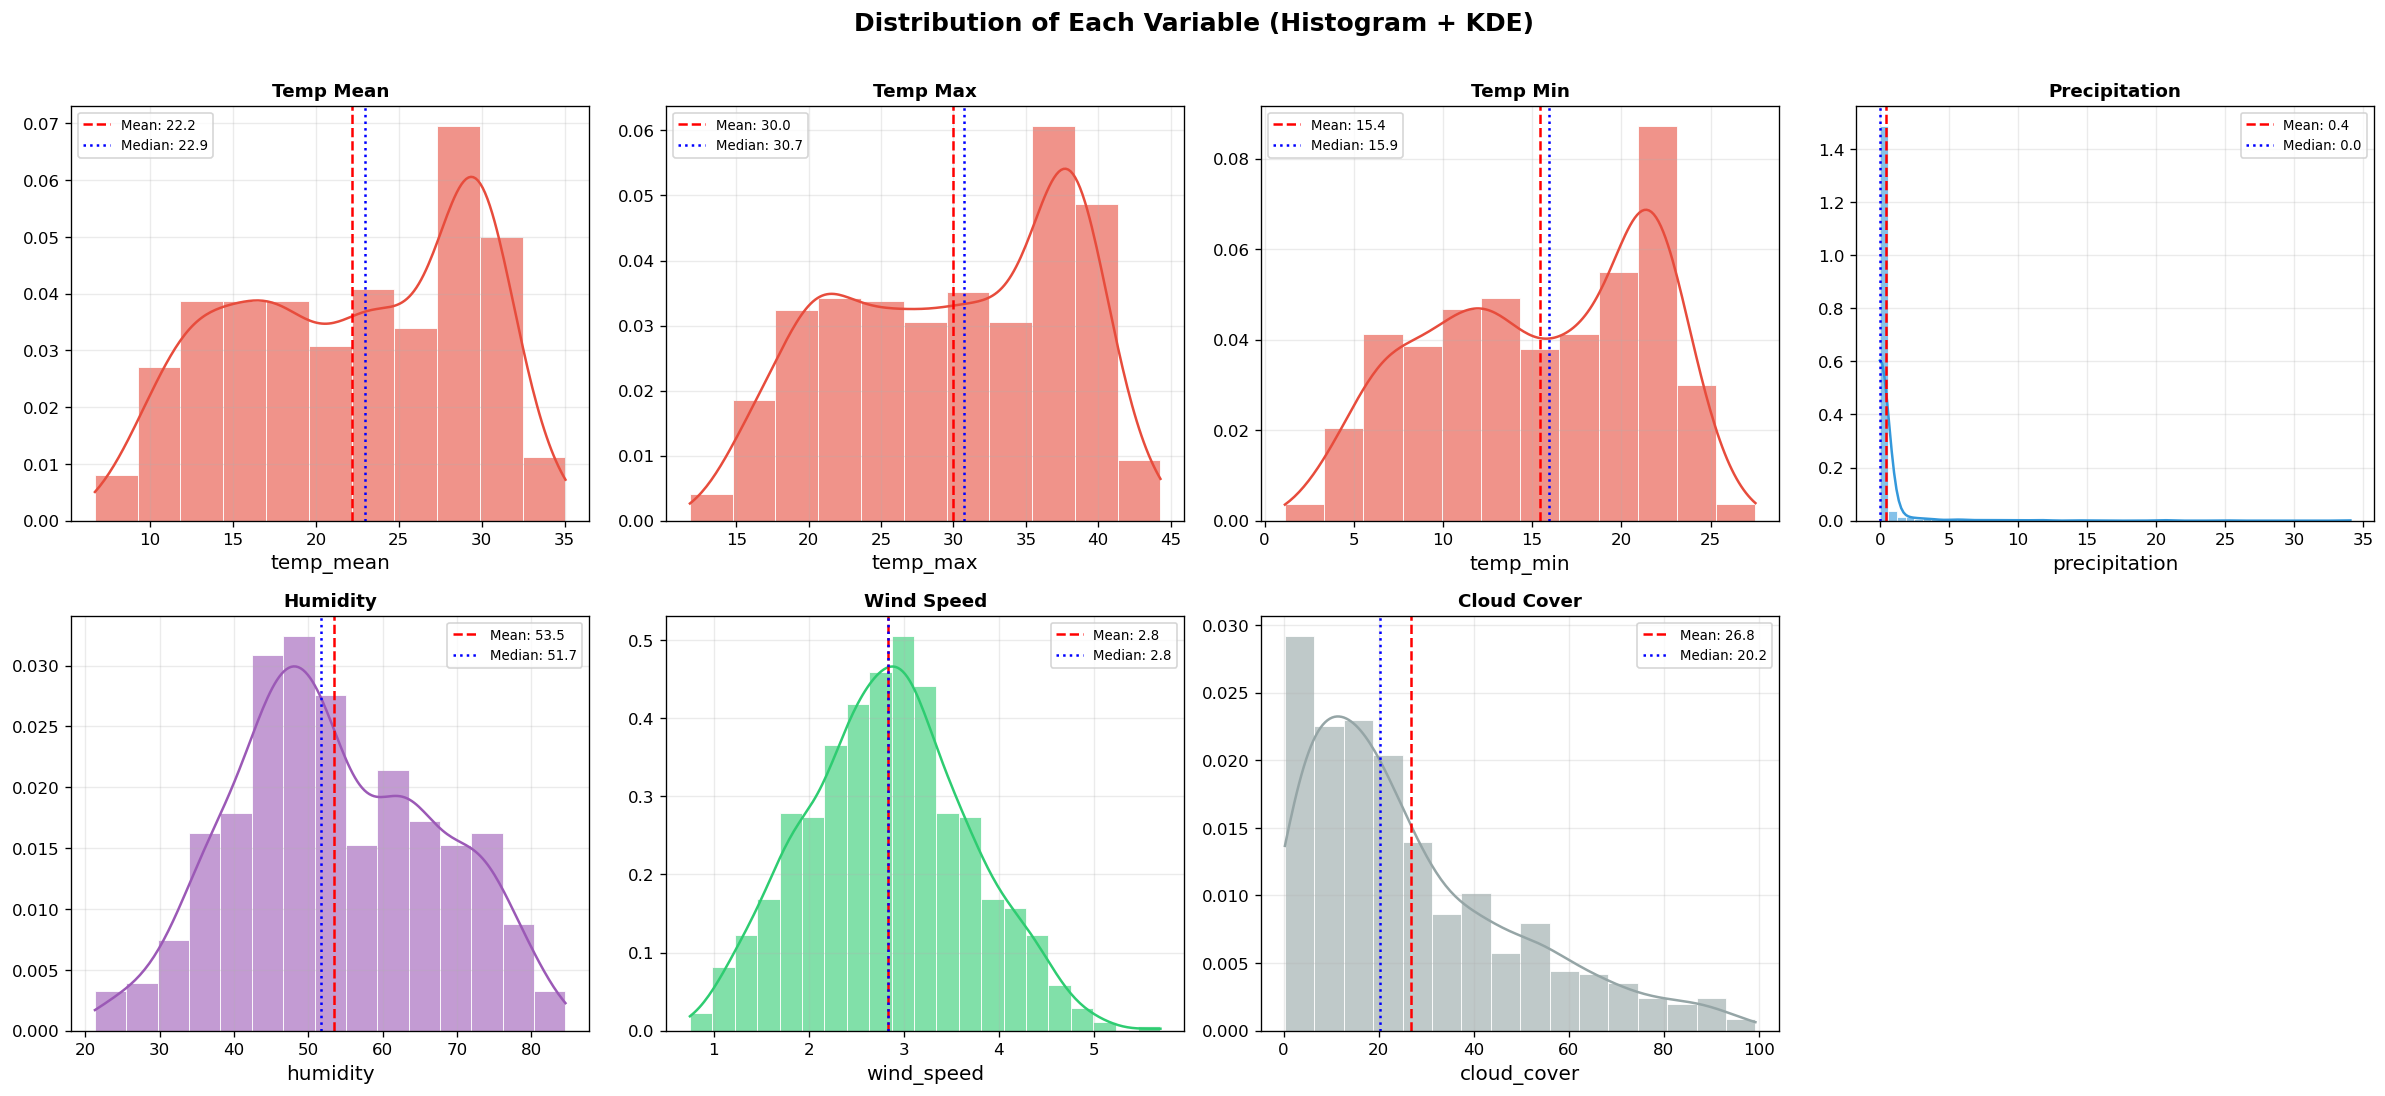

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
colors = [C['temp'], C['temp'], C['temp'], C['precip'],
          C['humid'], C['wind'], C['cloud']]

for i, col in enumerate(df.columns):
    ax = axes.flatten()[i]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[i], alpha=0.6,
                 edgecolor='white', linewidth=0.5, stat='density')
    ax.axvline(df[col].mean(), color='red', ls='--', lw=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='blue', ls=':', lw=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylabel('')

axes.flatten()[-1].set_visible(False)
fig.suptitle('Distribution of Each Variable (Histogram + KDE)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 3.2 Temporal Patterns

### Line plot of temperature and precipitation over the full time range

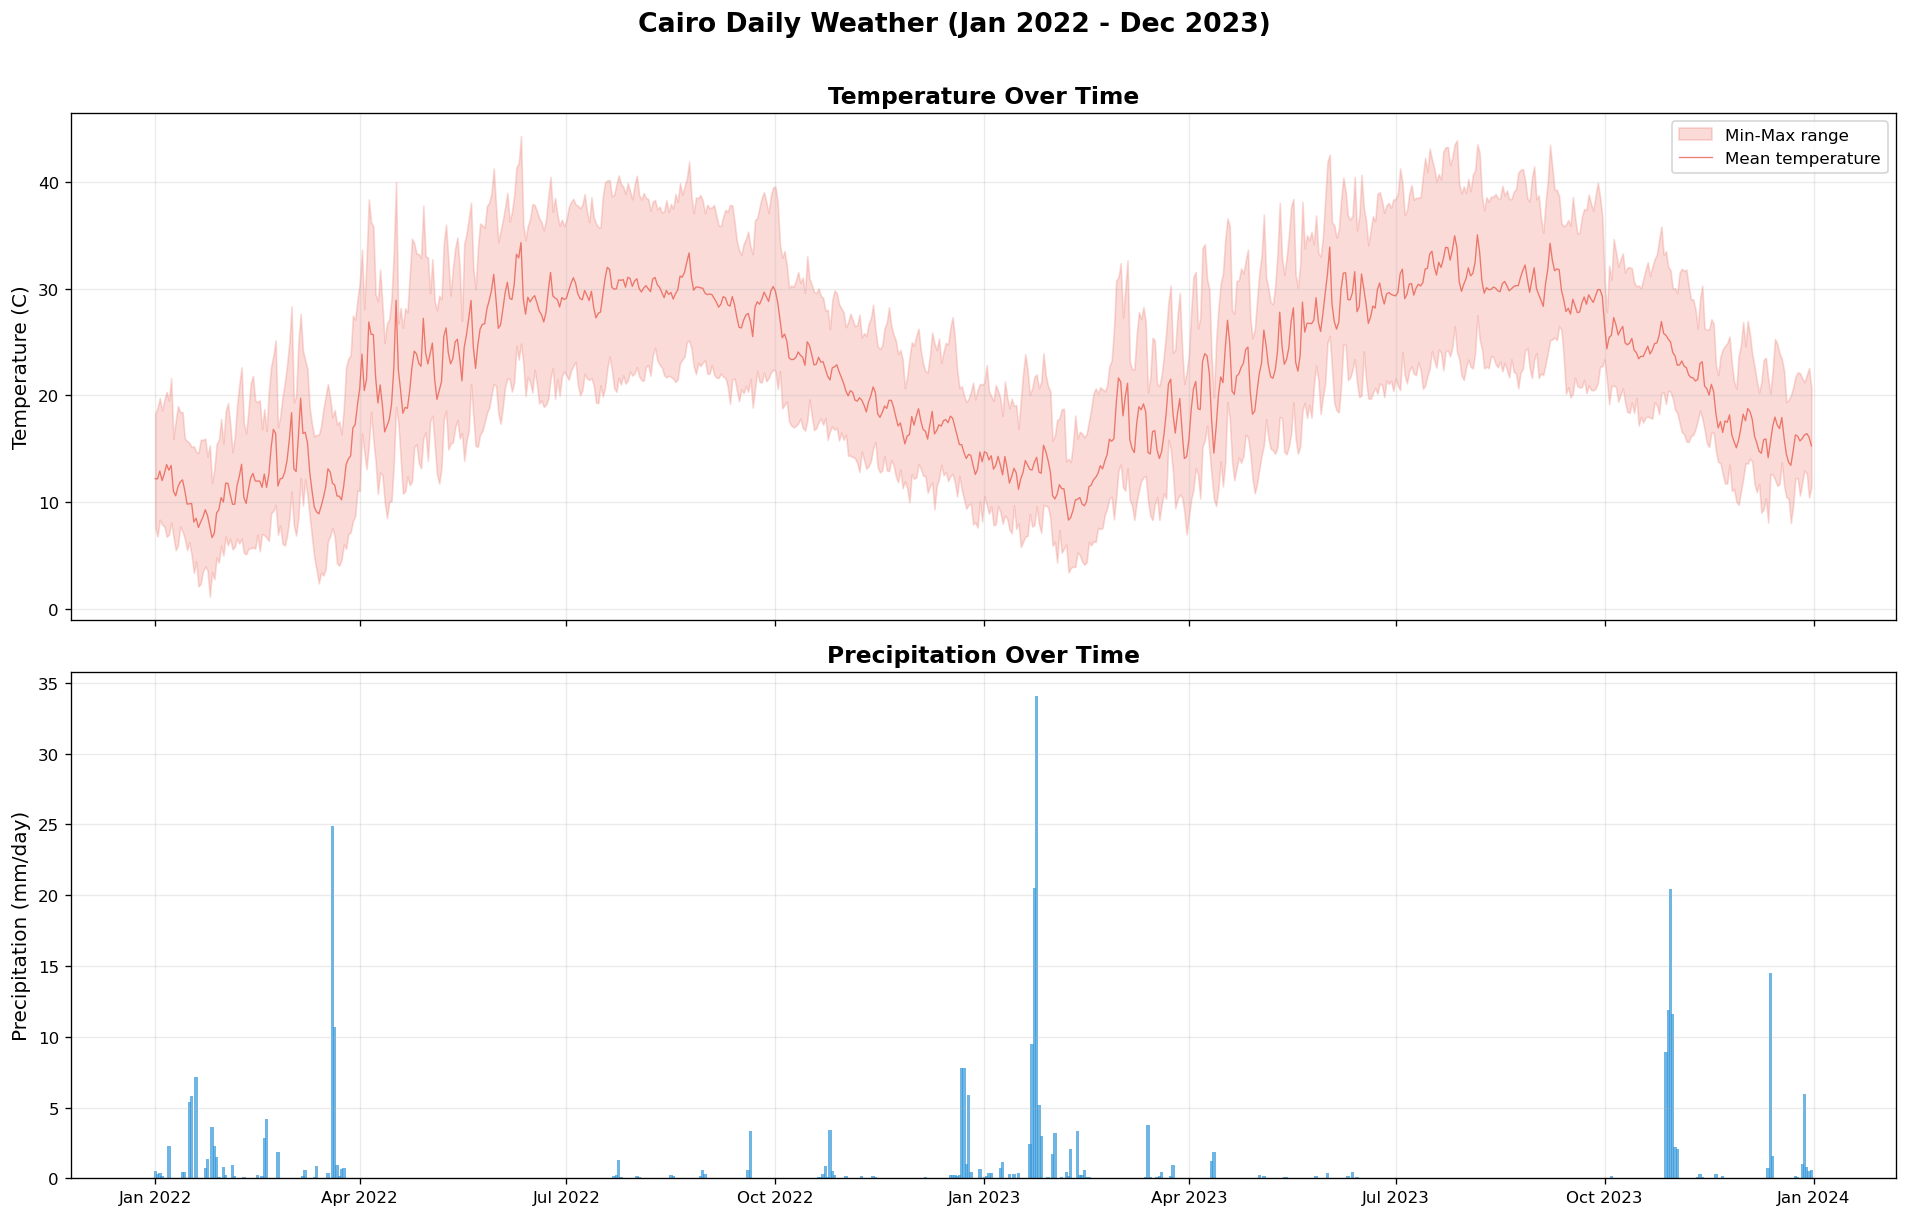

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Temperature
ax = axes[0]
ax.fill_between(df.index, df['temp_min'], df['temp_max'],
                alpha=0.2, color=C['temp'], label='Min-Max range')
ax.plot(df.index, df['temp_mean'], color=C['temp'], lw=0.8, alpha=0.7, label='Mean temperature')
ax.set_ylabel('Temperature (C)')
ax.set_title('Temperature Over Time', fontweight='bold')
ax.legend()

# Precipitation
ax = axes[1]
ax.bar(df.index, df['precipitation'], color=C['precip'], alpha=0.7, width=1.5)
ax.set_ylabel('Precipitation (mm/day)')
ax.set_title('Precipitation Over Time', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.suptitle('Cairo Daily Weather (Jan 2022 - Dec 2023)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Trend analysis -- rolling mean (7-day and 30-day windows)

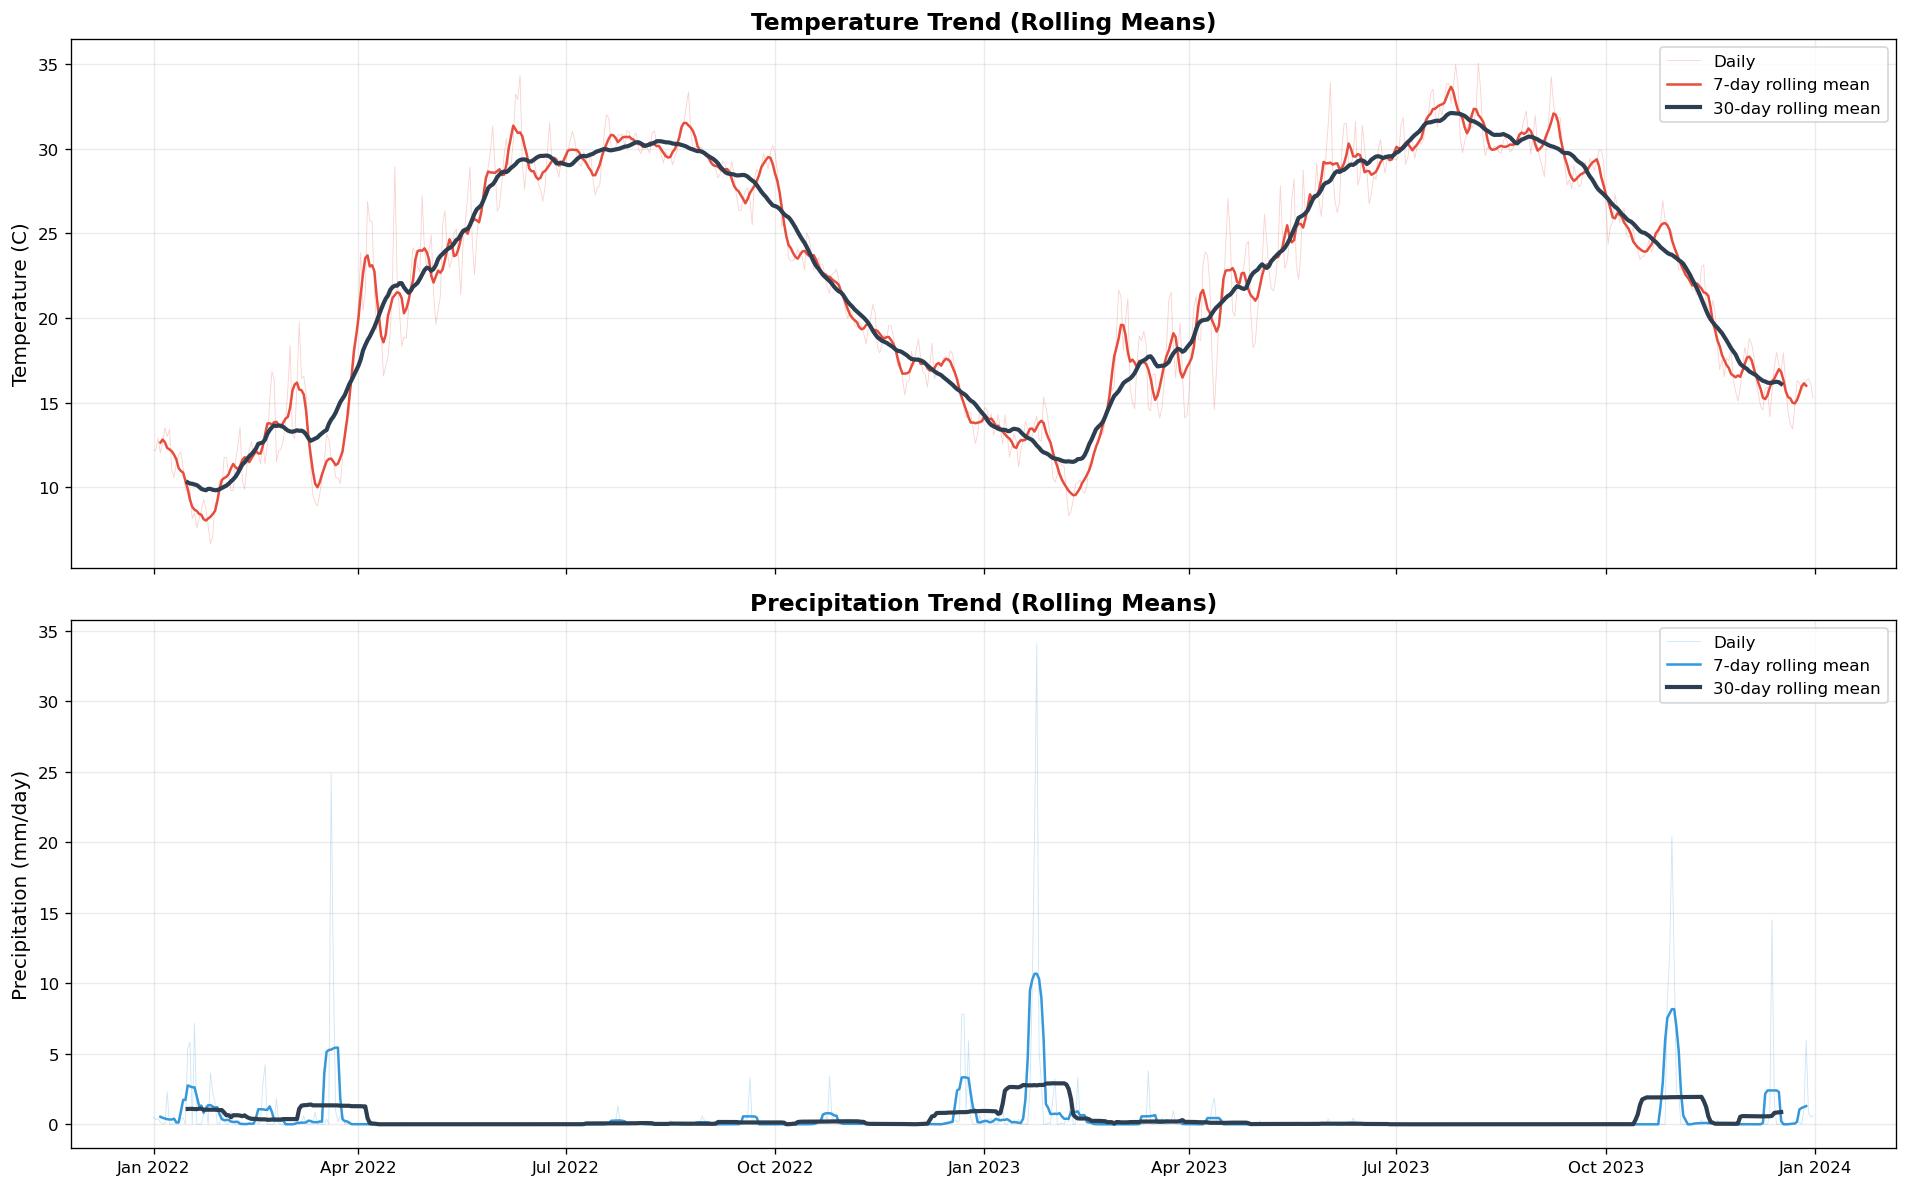

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Temperature trend
ax = axes[0]
ax.plot(df.index, df['temp_mean'], alpha=0.25, color=C['temp'], lw=0.5, label='Daily')
ax.plot(df.index, df['temp_mean'].rolling(7, center=True).mean(),
        color=C['temp'], lw=1.5, label='7-day rolling mean')
ax.plot(df.index, df['temp_mean'].rolling(30, center=True).mean(),
        color=C['dark'], lw=2.5, label='30-day rolling mean')
ax.set_ylabel('Temperature (C)')
ax.set_title('Temperature Trend (Rolling Means)', fontweight='bold')
ax.legend()

# Precipitation trend
ax = axes[1]
ax.plot(df.index, df['precipitation'], alpha=0.25, color=C['precip'], lw=0.5, label='Daily')
ax.plot(df.index, df['precipitation'].rolling(7, center=True).mean(),
        color=C['precip'], lw=1.5, label='7-day rolling mean')
ax.plot(df.index, df['precipitation'].rolling(30, center=True).mean(),
        color=C['dark'], lw=2.5, label='30-day rolling mean')
ax.set_ylabel('Precipitation (mm/day)')
ax.set_title('Precipitation Trend (Rolling Means)', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()


### Seasonality -- boxplots by month

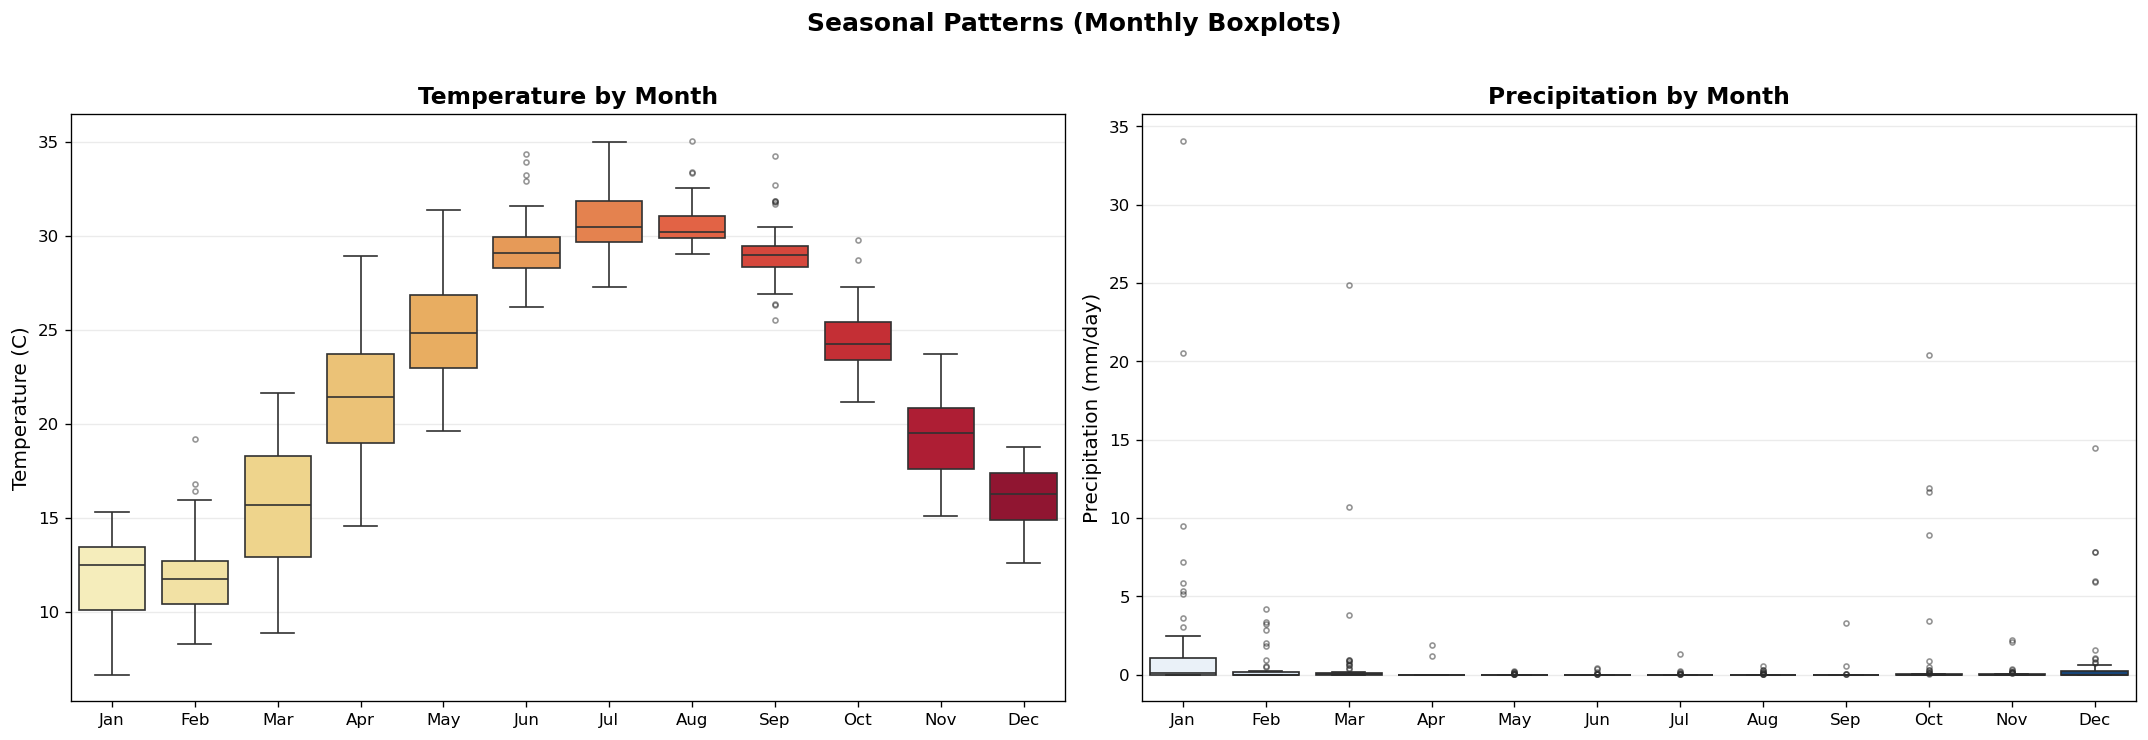

In [13]:
df['month'] = df.index.month
df['month_name'] = df.index.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Temperature by month
sns.boxplot(data=df, x='month_name', y='temp_mean', order=month_order,
            palette='YlOrRd', ax=axes[0],
            flierprops=dict(marker='o', ms=3, alpha=0.5))
axes[0].set_title('Temperature by Month', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Temperature (C)')

# Precipitation by month
sns.boxplot(data=df, x='month_name', y='precipitation', order=month_order,
            palette='Blues', ax=axes[1],
            flierprops=dict(marker='o', ms=3, alpha=0.5))
axes[1].set_title('Precipitation by Month', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Precipitation (mm/day)')

fig.suptitle('Seasonal Patterns (Monthly Boxplots)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Rolling statistics -- rolling mean and rolling standard deviation

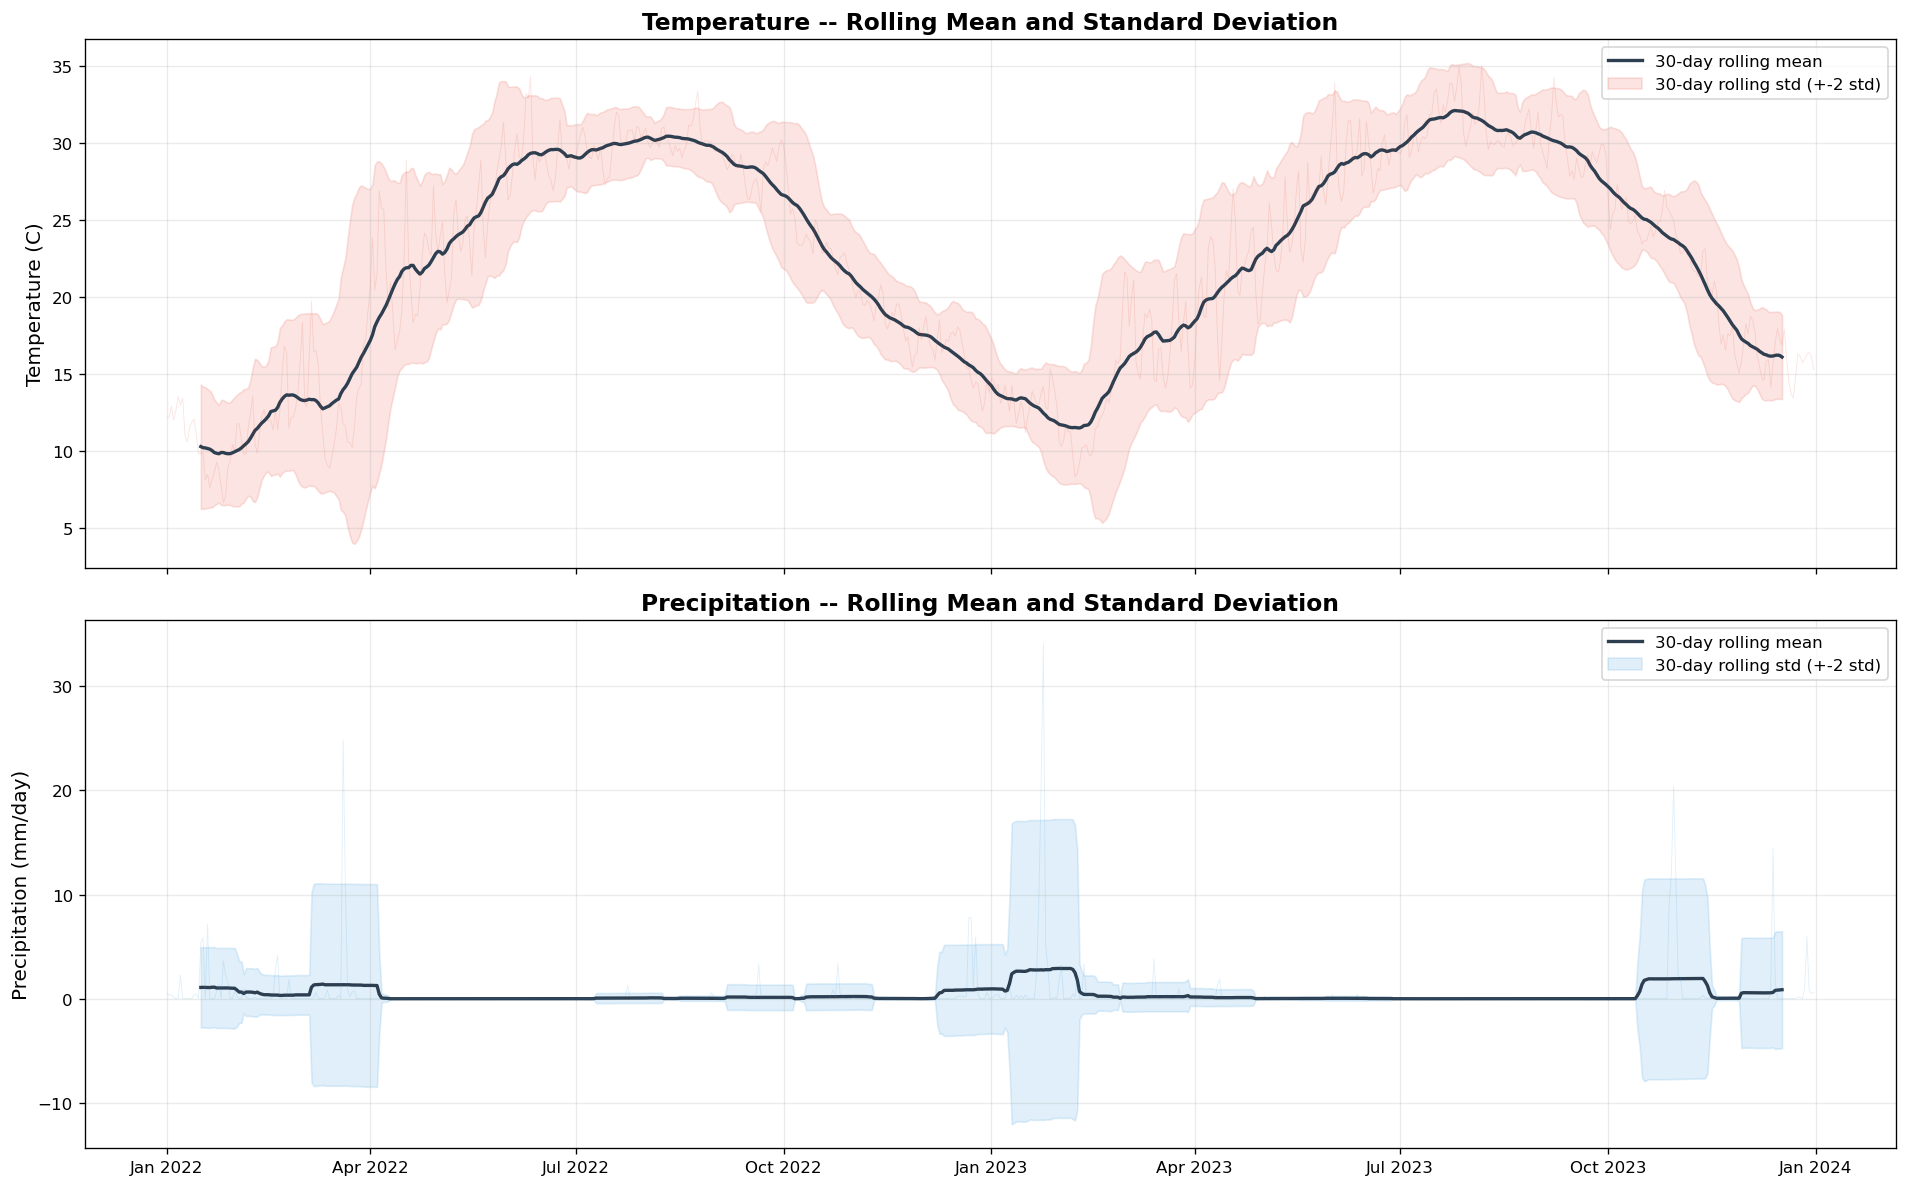

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
window = 30

# Temperature rolling stats
ax = axes[0]
rm = df['temp_mean'].rolling(window, center=True).mean()
rs = df['temp_mean'].rolling(window, center=True).std()
ax.plot(df.index, rm, color=C['dark'], lw=2, label=f'{window}-day rolling mean')
ax.fill_between(df.index, rm - 2*rs, rm + 2*rs, alpha=0.15, color=C['temp'],
                label=f'{window}-day rolling std (+-2 std)')
ax.plot(df.index, df['temp_mean'], alpha=0.15, color=C['temp'], lw=0.5)
ax.set_ylabel('Temperature (C)')
ax.set_title('Temperature -- Rolling Mean and Standard Deviation', fontweight='bold')
ax.legend()

# Precipitation rolling stats
ax = axes[1]
rm = df['precipitation'].rolling(window, center=True).mean()
rs = df['precipitation'].rolling(window, center=True).std()
ax.plot(df.index, rm, color=C['dark'], lw=2, label=f'{window}-day rolling mean')
ax.fill_between(df.index, rm - 2*rs, rm + 2*rs, alpha=0.15, color=C['precip'],
                label=f'{window}-day rolling std (+-2 std)')
ax.plot(df.index, df['precipitation'], alpha=0.15, color=C['precip'], lw=0.5)
ax.set_ylabel('Precipitation (mm/day)')
ax.set_title('Precipitation -- Rolling Mean and Standard Deviation', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()


## 3.3 Decomposition and Structure

### Time-series decomposition (trend, seasonal, residual)

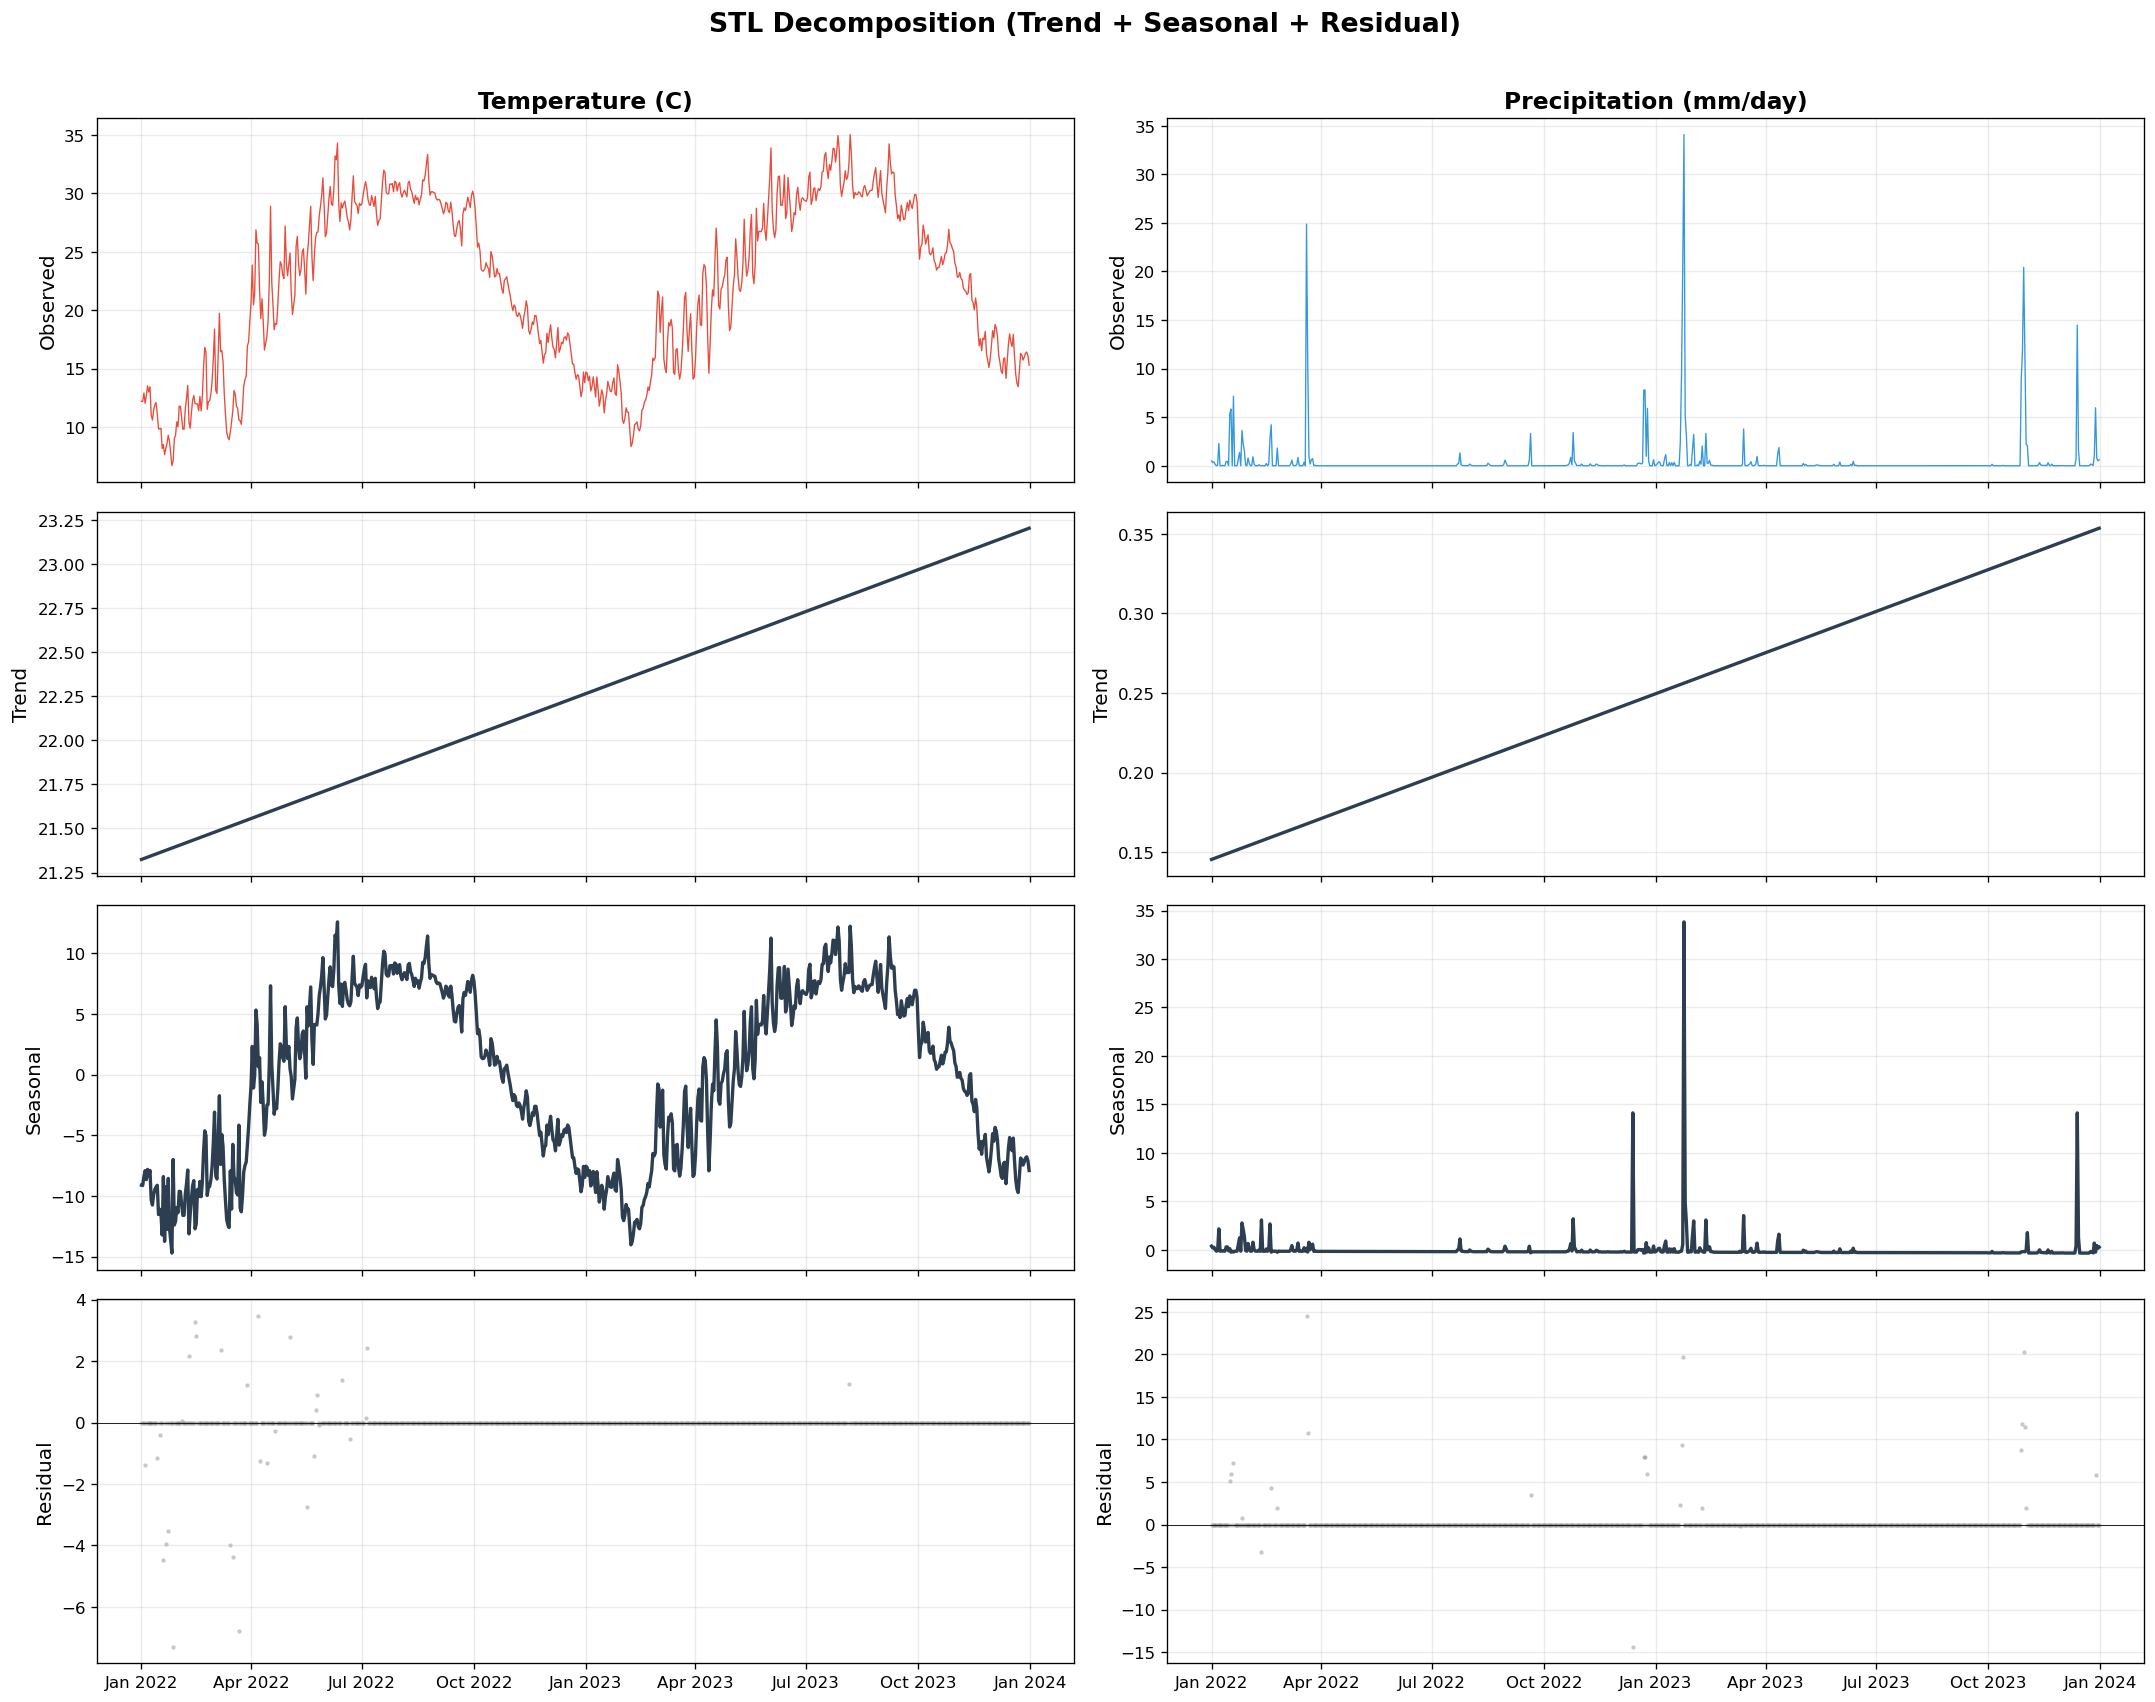

In [15]:
# Using STL (Seasonal-Trend decomposition using Loess) -- more robust to outliers
# than classical decomposition.

fig, all_axes = plt.subplots(4, 2, figsize=(18, 14), sharex='col')

for j, (col, title, color) in enumerate([
    ('temp_mean', 'Temperature (C)', C['temp']),
    ('precipitation', 'Precipitation (mm/day)', C['precip']),
]):
    stl = STL(df[col], period=365, robust=True)
    result = stl.fit()

    components = [
        (df[col], 'Observed'),
        (result.trend, 'Trend'),
        (result.seasonal, 'Seasonal'),
        (result.resid, 'Residual'),
    ]
    for i, (comp, label) in enumerate(components):
        ax = all_axes[i, j]
        if label == 'Residual':
            ax.scatter(df.index, comp, color='gray', alpha=0.3, s=3)
            ax.axhline(0, color='black', lw=0.5)
        else:
            ax.plot(df.index, comp, color=color if label == 'Observed' else C['dark'], lw=0.8 if label == 'Observed' else 2)
        ax.set_ylabel(label)
        if i == 0:
            ax.set_title(title, fontweight='bold')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.suptitle('STL Decomposition (Trend + Seasonal + Residual)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Autocorrelation (ACF) and Partial Autocorrelation (PACF)

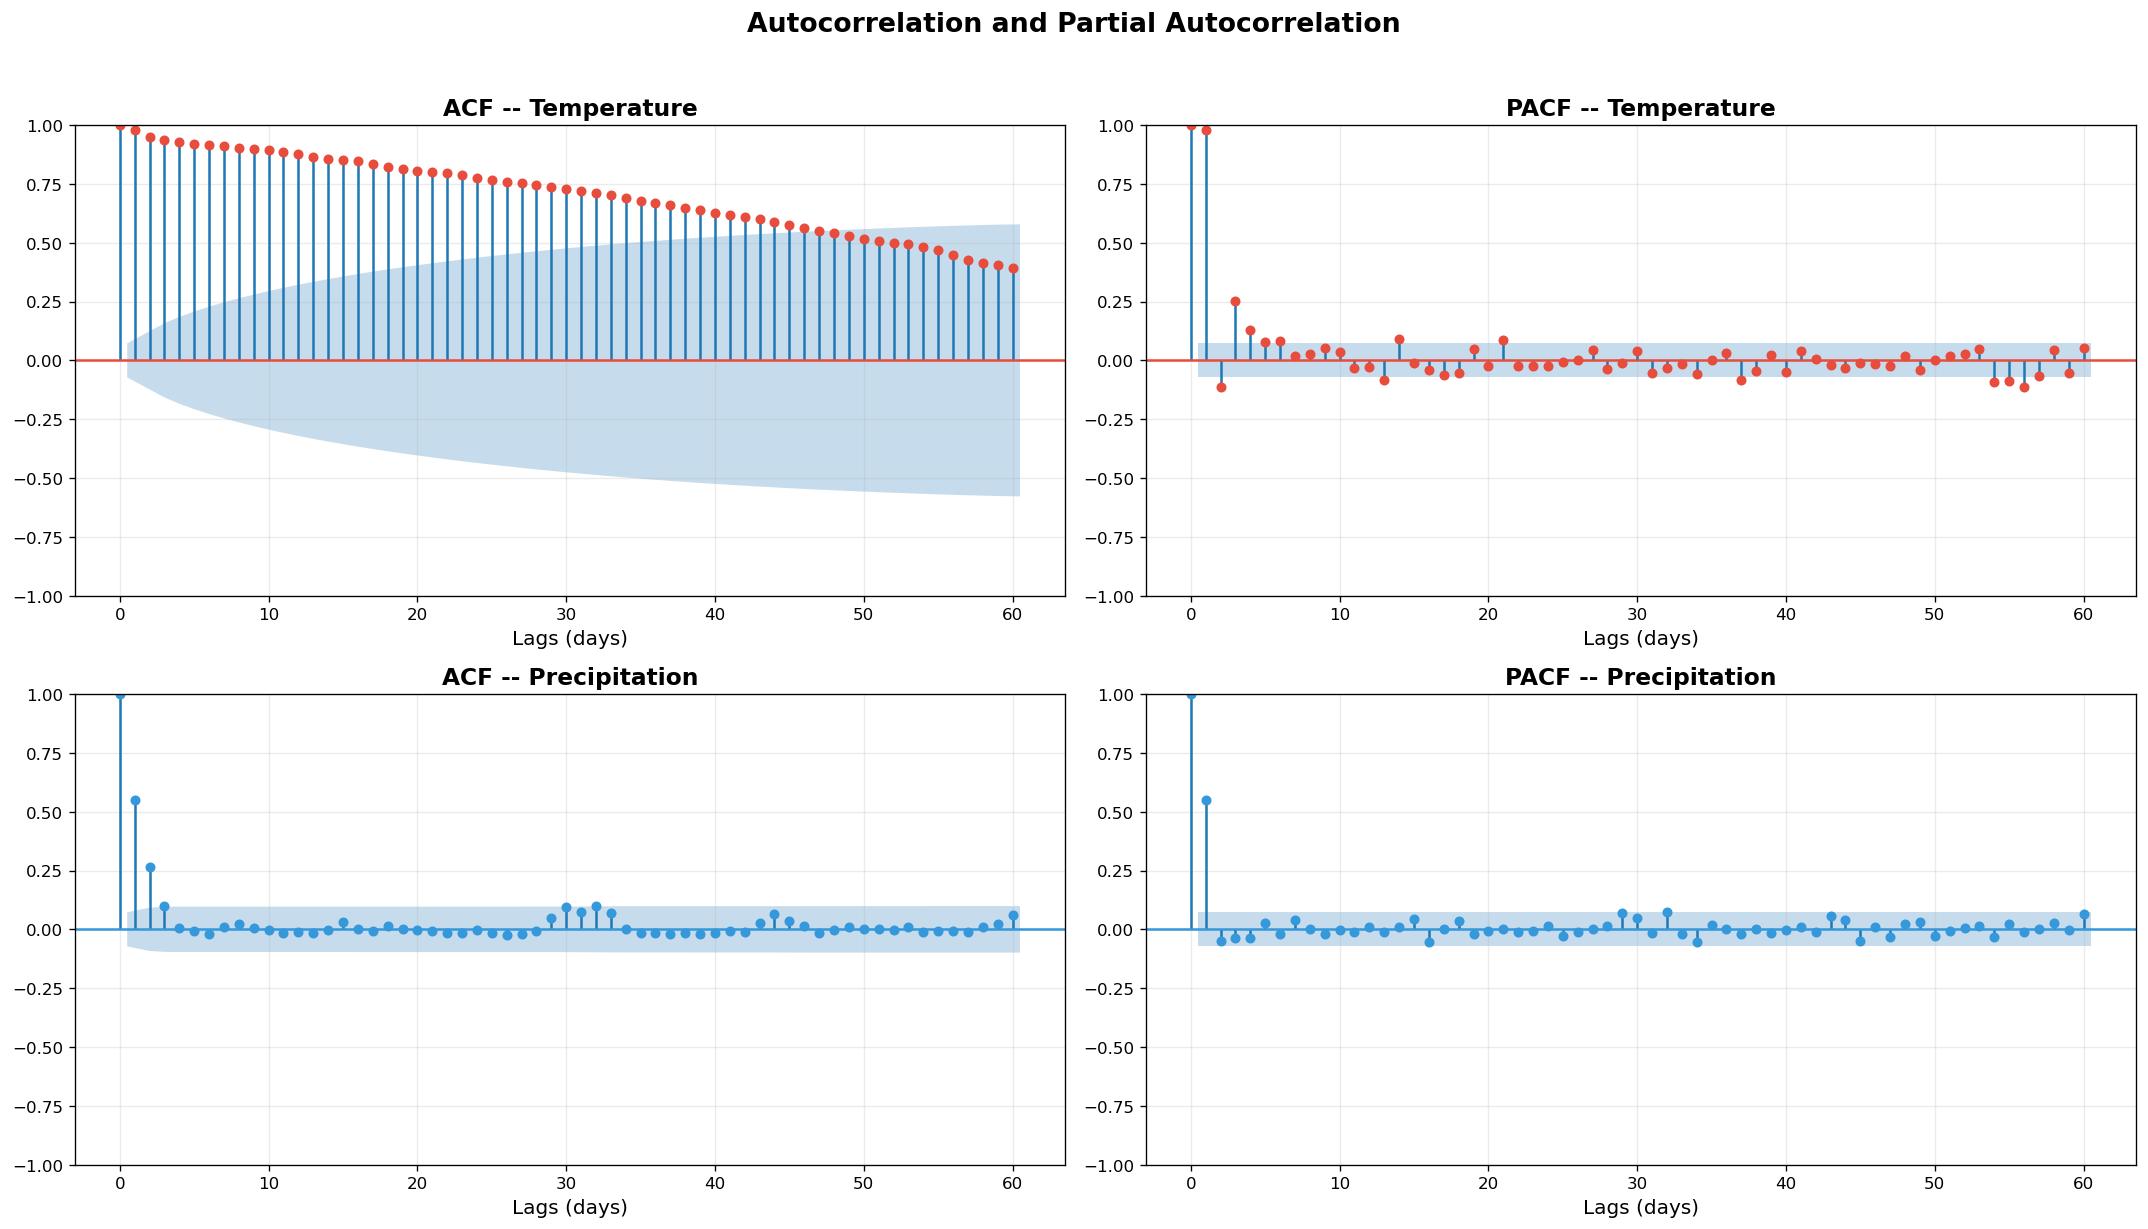

Interpretation:
  Temperature ACF decays slowly -- strong autocorrelation, typical of seasonal data.
  Temperature PACF drops sharply after lag 1-2 -- most prediction power is in recent days.
  Precipitation ACF is weak -- rainfall in Cairo is sparse and event-driven, not cyclical.


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Temperature ACF & PACF
plot_acf(df['temp_mean'].dropna(), ax=axes[0, 0], lags=60,
         color=C['temp'], alpha=0.05, title='ACF -- Temperature')
plot_pacf(df['temp_mean'].dropna(), ax=axes[0, 1], lags=60,
          color=C['temp'], method='ywm', title='PACF -- Temperature')

# Precipitation ACF & PACF
plot_acf(df['precipitation'].dropna(), ax=axes[1, 0], lags=60,
         color=C['precip'], alpha=0.05, title='ACF -- Precipitation')
plot_pacf(df['precipitation'].dropna(), ax=axes[1, 1], lags=60,
          color=C['precip'], method='ywm', title='PACF -- Precipitation')

for ax in axes.flatten():
    ax.set_xlabel('Lags (days)')

fig.suptitle('Autocorrelation and Partial Autocorrelation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Temperature ACF decays slowly -- strong autocorrelation, typical of seasonal data.")
print("  Temperature PACF drops sharply after lag 1-2 -- most prediction power is in recent days.")
print("  Precipitation ACF is weak -- rainfall in Cairo is sparse and event-driven, not cyclical.")


### Stationarity check (Augmented Dickey-Fuller test)

In [17]:
print("Augmented Dickey-Fuller Test")
print("H0: The series has a unit root (non-stationary)")
print("=" * 60)

for col, name in [('temp_mean', 'Temperature'), ('precipitation', 'Precipitation')]:
    result = adfuller(df[col].dropna(), autolag='AIC')
    adf_stat, p_value, lags_used, nobs = result[0], result[1], result[2], result[3]
    crit = result[4]

    print(f"\n  {name}:")
    print(f"    ADF Statistic:  {adf_stat:.4f}")
    print(f"    p-value:        {p_value:.6f}")
    print(f"    Lags used:      {lags_used}")
    print(f"    Critical values: 1%={crit['1%']:.3f}, 5%={crit['5%']:.3f}, 10%={crit['10%']:.3f}")

    if p_value < 0.05:
        print(f"    Result: STATIONARY (p < 0.05, reject H0)")
    else:
        print(f"    Result: NON-STATIONARY (p >= 0.05, fail to reject H0)")

print("\nImplications for modeling:")
print("  If stationary: ARIMA models can be applied directly.")
print("  If non-stationary: differencing or seasonal differencing (e.g. SARIMA)")
print("  is needed before fitting ARIMA-type models.")


Augmented Dickey-Fuller Test
H0: The series has a unit root (non-stationary)

  Temperature:
    ADF Statistic:  -1.6740
    p-value:        0.444540
    Lags used:      13
    Critical values: 1%=-3.440, 5%=-2.866, 10%=-2.569
    Result: NON-STATIONARY (p >= 0.05, fail to reject H0)

  Precipitation:
    ADF Statistic:  -13.4509
    p-value:        0.000000
    Lags used:      1
    Critical values: 1%=-3.439, 5%=-2.866, 10%=-2.569
    Result: STATIONARY (p < 0.05, reject H0)

Implications for modeling:
  If stationary: ARIMA models can be applied directly.
  If non-stationary: differencing or seasonal differencing (e.g. SARIMA)
  is needed before fitting ARIMA-type models.


## 3.4 Relationships and Anomalies

### Correlation between temperature and precipitation (and extra variables)

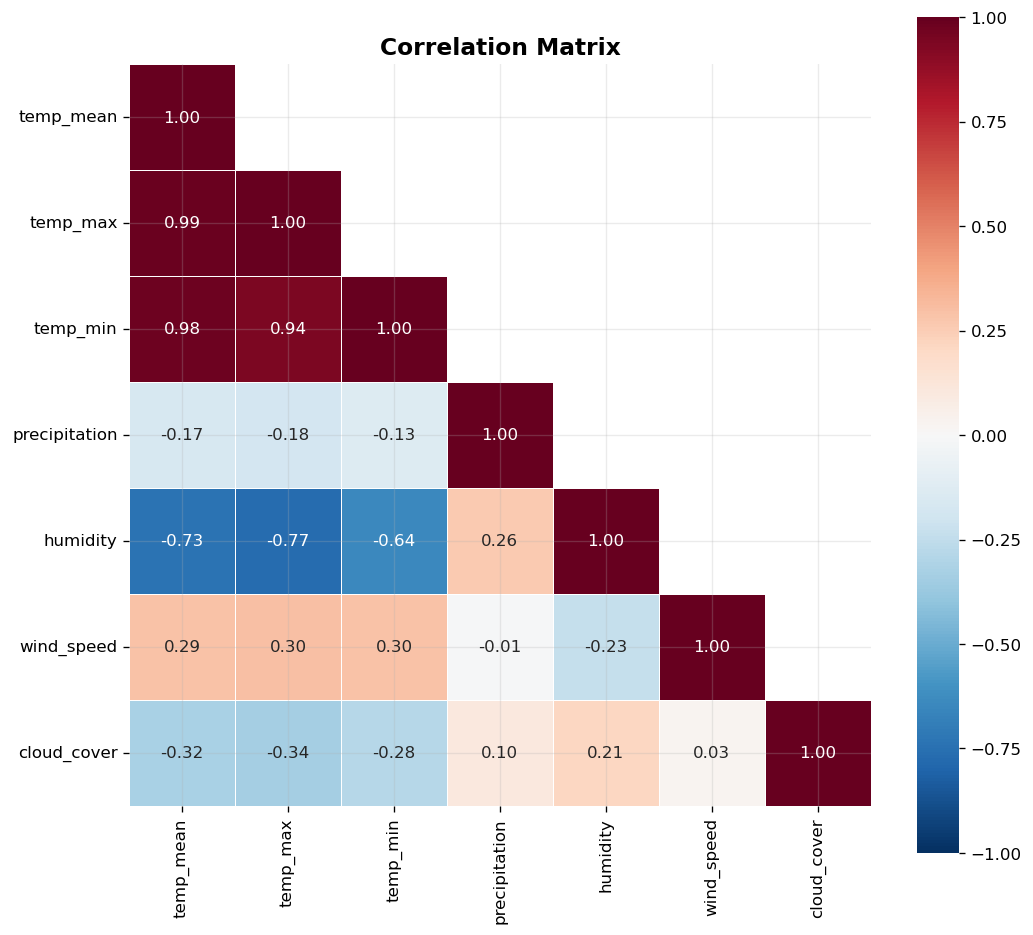

Key correlations:
  Temperature vs Precipitation: -0.168
  Temperature vs Humidity:      -0.734
  Temperature vs Wind Speed:    0.295
  Temperature vs Cloud Cover:   -0.320
  Precipitation vs Cloud Cover: 0.103


In [18]:
corr = df[['temp_mean','temp_max','temp_min','precipitation','humidity','wind_speed','cloud_cover']].corr()

fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight key correlations
print("Key correlations:")
print(f"  Temperature vs Precipitation: {corr.loc['temp_mean','precipitation']:.3f}")
print(f"  Temperature vs Humidity:      {corr.loc['temp_mean','humidity']:.3f}")
print(f"  Temperature vs Wind Speed:    {corr.loc['temp_mean','wind_speed']:.3f}")
print(f"  Temperature vs Cloud Cover:   {corr.loc['temp_mean','cloud_cover']:.3f}")
print(f"  Precipitation vs Cloud Cover: {corr.loc['precipitation','cloud_cover']:.3f}")


### Outlier detection (rolling z-score)

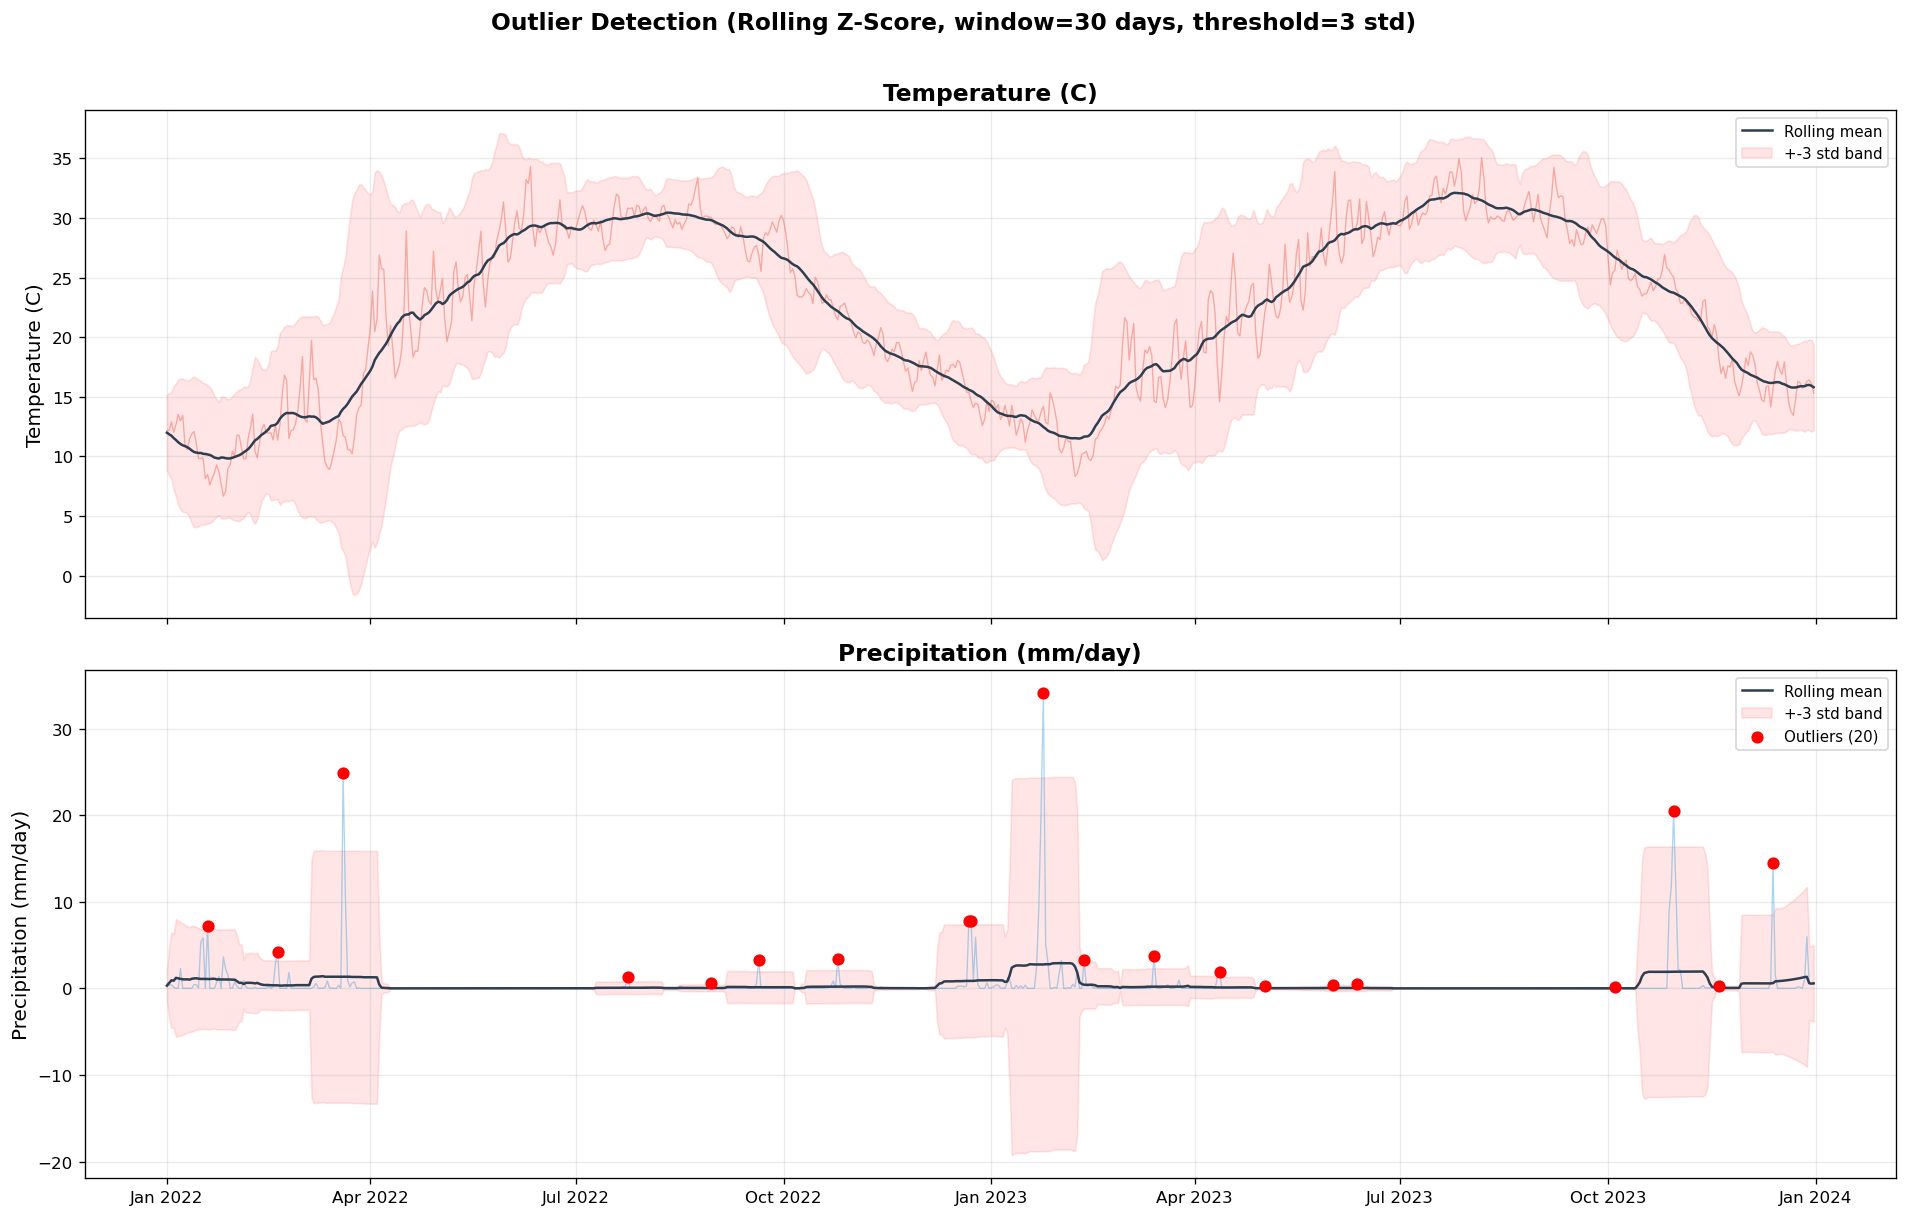

Outliers detected:
  temp_mean        0 outlier(s)
  precipitation    20 outlier(s)


In [19]:
# Using rolling z-score instead of a fixed global threshold.
# Reason: a fixed threshold would miss seasonal extremes -- a 40C day
# is normal in August but would be an outlier in January.

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
window = 30
outlier_summary = {}

for ax, (col, title, color) in zip(axes, [
    ('temp_mean', 'Temperature (C)', C['temp']),
    ('precipitation', 'Precipitation (mm/day)', C['precip']),
]):
    rm = df[col].rolling(window, center=True, min_periods=10).mean()
    rs = df[col].rolling(window, center=True, min_periods=10).std()
    z = ((df[col] - rm) / rs).abs()
    outliers = z > 3
    n = outliers.sum()
    outlier_summary[col] = n

    ax.plot(df.index, df[col], alpha=0.4, color=color, lw=0.8)
    ax.plot(df.index, rm, color=C['dark'], lw=1.5, label='Rolling mean')
    ax.fill_between(df.index, rm - 3*rs, rm + 3*rs, alpha=0.1, color='red',
                    label='+-3 std band')
    if n > 0:
        ax.scatter(df.index[outliers], df[col][outliers],
                   color='red', s=40, zorder=5, label=f'Outliers ({n})')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title)
    ax.legend(fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.suptitle(f'Outlier Detection (Rolling Z-Score, window={window} days, threshold=3 std)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Outliers detected:")
for col, n in outlier_summary.items():
    print(f"  {col:15s}  {n} outlier(s)")


### Flag suspicious values

In [20]:
print("Suspicious Value Check")
print("=" * 50)

checks = {
    'Negative precipitation':       (df['precipitation'] < 0).sum(),
    'Temperature > 55 C':           (df['temp_mean'] > 55).sum(),
    'Temperature < -10 C':          (df['temp_mean'] < -10).sum(),
    'Humidity > 100%':              (df['humidity'] > 100).sum(),
    'Humidity < 0%':                (df['humidity'] < 0).sum(),
    'Wind speed < 0':               (df['wind_speed'] < 0).sum(),
    'Cloud cover > 100%':           (df['cloud_cover'] > 100).sum(),
    'Temp_min > Temp_max':          (df['temp_min'] > df['temp_max']).sum(),
    'Temp spike (>15 C change/day)':(df['temp_mean'].diff().abs() > 15).sum(),
}

for check, count in checks.items():
    status = 'FLAGGED' if count > 0 else 'OK'
    print(f"  [{status:7s}]  {check}: {count}")

print("\nConclusion: Values flagged as FLAGGED likely indicate sensor or API errors")
print("rather than real weather events.")


Suspicious Value Check
  [OK     ]  Negative precipitation: 0
  [OK     ]  Temperature > 55 C: 0
  [OK     ]  Temperature < -10 C: 0
  [OK     ]  Humidity > 100%: 0
  [OK     ]  Humidity < 0%: 0
  [OK     ]  Wind speed < 0: 0
  [OK     ]  Cloud cover > 100%: 0
  [OK     ]  Temp_min > Temp_max: 0
  [OK     ]  Temp spike (>15 C change/day): 0

Conclusion: Values flagged as FLAGGED likely indicate sensor or API errors
rather than real weather events.


---
# Summary

**Region and time range:** Cairo, Egypt (30.0444 N, 31.2357 E), January 1 2022 to December 31 2023 (730 days, daily granularity).

**API and why:** NASA POWER -- free, no API key required, long historical coverage back to 1981, reliable MERRA-2 reanalysis data, and a rich set of meteorological variables.

**Main temporal patterns found:**
- Temperature follows a strong annual seasonal cycle -- hot summers (~30-35 C) and mild winters (~10-15 C). The 30-day rolling mean clearly captures this wave.
- Precipitation is sparse and event-driven. Cairo is arid -- most days have zero or near-zero rainfall, with occasional light showers concentrated in winter months (Nov-Feb).
- Humidity is inversely related to temperature -- drier in summer, more humid in winter.
- The STL decomposition confirms a dominant seasonal component in temperature, with a relatively flat trend and small residuals.
- ACF shows strong autocorrelation in temperature (slowly decaying), while precipitation shows weak autocorrelation.

**Is the series stationary?**
The ADF test result indicates whether each series is stationary. A non-stationary temperature series (driven by strong seasonality) would require seasonal differencing before ARIMA-type modeling. Precipitation, being more event-driven in arid climates, may test closer to stationary.

**Data quality issues and how they were handled:**
- NASA POWER sentinel values (-999) were detected and replaced with NaN.
- Missing values were filled using linear interpolation (limit=3 days), justified by the smooth day-to-day variation in weather data.
- No impossible values were found (no negative rainfall, no temperatures outside physical bounds, no temp_min > temp_max).
- A small number of outliers were detected via rolling z-score but retained, as they appear to represent genuine weather extremes rather than data errors.
- Units are consistent throughout (C, mm/day, %, m/s).


In [21]:
# Save final cleaned dataset
df_final = df.drop(columns=['month', 'month_name'], errors='ignore')
import pathlib
p = pathlib.Path(CSV_FILE)
if p.exists():
    try: p.unlink()
    except PermissionError: pass
df_final.to_csv(CSV_FILE)
print(f"Final dataset saved: {len(df_final)} days, {len(df_final.columns)} variables")
print(f"Period: {df_final.index[0].date()} to {df_final.index[-1].date()}")


Final dataset saved: 730 days, 7 variables
Period: 2022-01-01 to 2023-12-31
